# [LAB-09] 1. 단순선형회귀 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame, concat

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 데이터 가져오기

In [2]:
df = load_data("father-son")
df.head()

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)


,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281


## 문제 풀이

### Mission 1. 데이터와 친해지기 (EDA)

father-son 데이터를 불러와 크기·자료형·기초통계량을 확인하라.

산점도(scatter plot)를 그려 아버지 키(fheight)와 아들 키(sheight) 사이에 어떤 경향이 보이는지 눈으로 관찰하라.

두 변수의 상관계수를 구하고, 회귀분석을 적용해도 되는지 근거를 대라.

#### 크기, 자료형, 기초통계량

In [3]:
print("데이터 크기:", df.shape)

데이터 크기: (1078, 2)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fheight  1078 non-null   float64
 1   sheight  1078 non-null   float64
dtypes: float64(2)
memory usage: 17.0 KB


In [5]:
my_qtcheck.numerical_summary(df).T

,fheight,sheight
count,1078.000,1078.000
mean,67.687,68.684
std,2.745,2.815
min,59.008,58.507
25%,65.788,66.931
50%,67.767,68.616
75%,69.603,70.466
max,75.434,78.365
rel_diff,0.001,0.001
rdiff_flag,similar,similar


#### 산점도 + 상관분석

`my_stats.correlation()` 은 정규성·선형성·영향점 가정을 자동 점검해 **Pearson / Spearman** 을 선택하고,
상관계수·유의확률·강도를 한 번에 산출하며 산점도를 함께 그려준다.

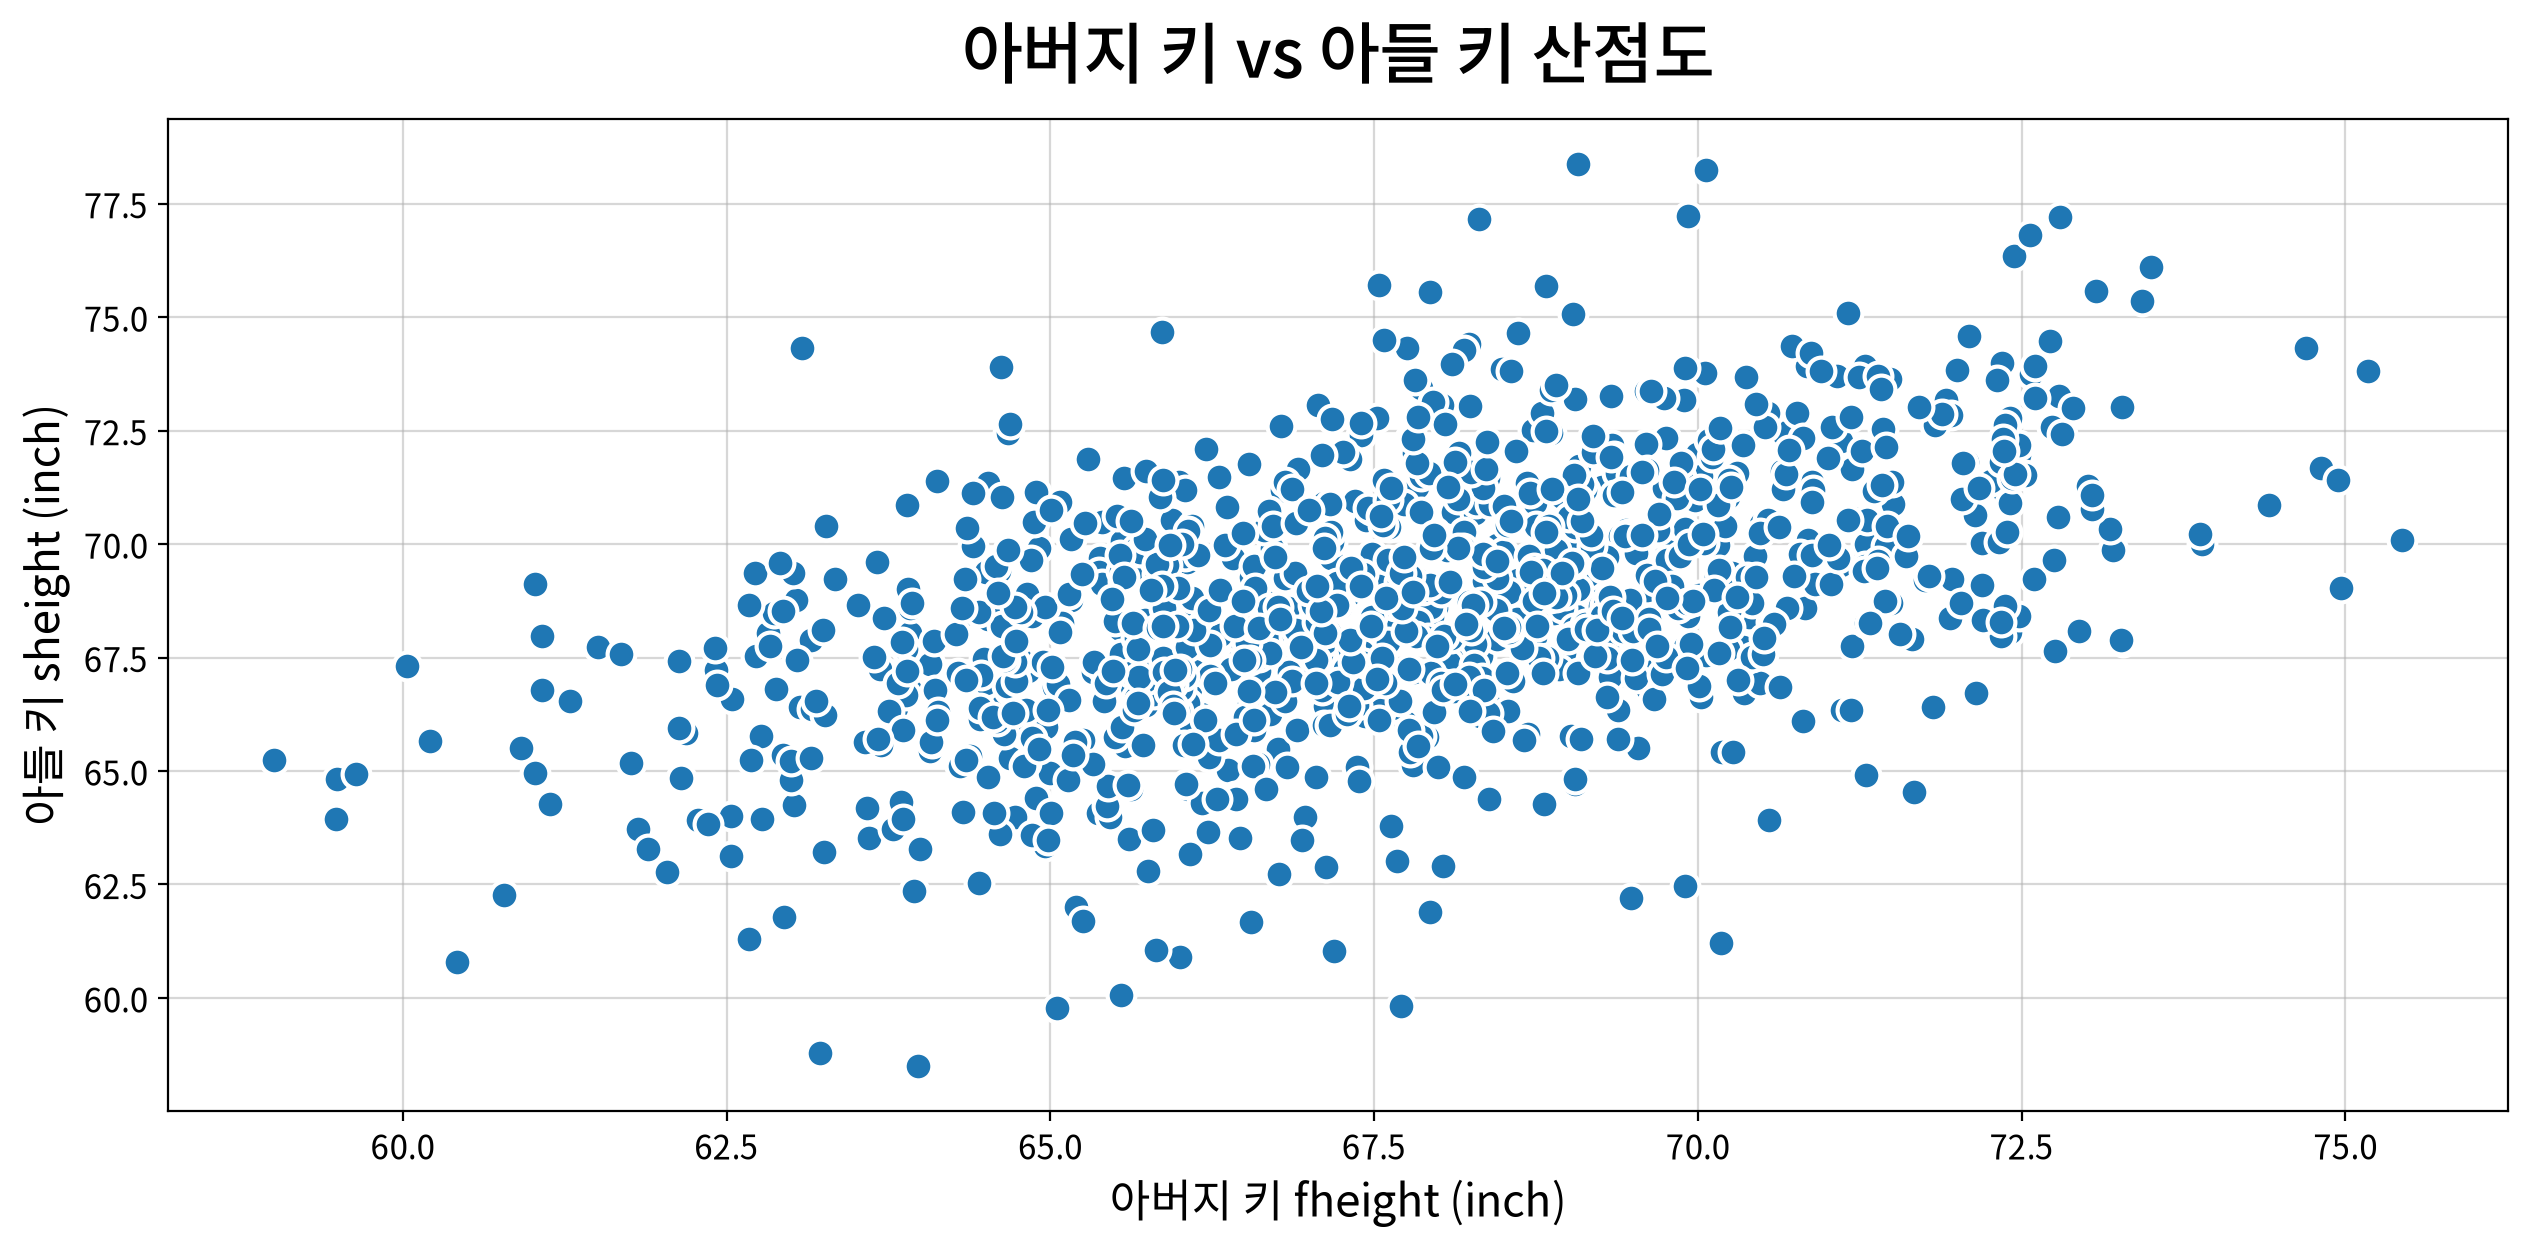

x,fheight
y,sheight
method,Spearman
coef,0.506
p-value,0.000
strength,Moderate
significant,True
normality_x,True
normality_y,False
linearity,True
influential_outlier,False


In [6]:
# --- 상관분석(가정 점검 포함) + 산점도 ---
corr = my_stats.correlation(
    df, x='fheight', y='sheight',
    title='아버지 키 vs 아들 키 산점도',
    xlabel='아버지 키 fheight (inch)', ylabel='아들 키 sheight (inch)',
)
corr.T

#### 🔎 관찰 및 회귀분석 가능 여부 판단

- **경향** : 산점도를 보면 아버지 키(fheight)가 클수록 아들 키(sheight)도 커지는 **우상향(양의) 선형 경향**이 보인다.
- **상관계수** : 위 표의 `coef` — 약 0.5 수준의 **양의 중간(Moderate) 상관**이며 `significant=True`(p<0.05)로 통계적으로 유의하다.
- **선형성** : `linearity=True` — Ramsey RESET 검정에서 계결림이 남지 않아 직선 관계로 설명 가능하다.

→ 두 변수는 **유의한 양의 선형 관계**를 가지므로, 아버지 키로 아들 키를 설명하는 **단순선형회귀 적용이 타당**하다.

### Mission 2. 회귀식 유도하기

아들 키(`sheight`)를 **종속변수**, 아버지 키(`fheight`)를 **독립변수**로 하는 단순선형회귀 모형을 적합한다.

In [7]:
fit = my_ols.fit_model(df, y='sheight', summary=True)

                            OLS Regression Results                            
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.12e-69
Time:                        06:23:14   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

#### 🔎 회귀식 유도

$sheight = 33.887 + 0.514 \times fheight$

### Mission 3. 미지의 5명, 그 아들들의 키를 예측하라

새 등록 신청자 5명의 아버지 키 `[73.5, 72.6, 68.3, 71.9, 74.1]` 을 원본 데이터와 병합한 새 데이터셋을 만들고, 앞서 유도한 회귀식으로 아들 키를 예측한다.

In [8]:
# --- 새 신청자 5명의 아버지 키 ---
new_fheight = [73.5, 72.6, 68.3, 71.9, 74.1]
new_x = DataFrame({'fheight': new_fheight})
new_x

,fheight
0,73.500
1,72.600
2,68.300
3,71.900
4,74.100


In [9]:
# --- 회귀식으로 아들 키 예측 (my_ols.predict) ---
pred = my_ols.predict(fit, new_x)

# 예측된 아들 키를 sheight 컴럼으로 붙인 가상 데이터 5건
new_df = new_x.copy()
new_df['sheight'] = pred['pred'].values
new_df

,fheight,sheight
0,73.500,71.672
1,72.600,71.210
2,68.300,68.999
3,71.900,70.850
4,74.100,71.981


In [10]:
# --- 원본 1,078건 + 가상 5건 병합하여 새 데이터셋 구성 ---
real_df = df.copy()
real_df['source'] = '실제 데이터'
new_df['source'] = '가상 데이터'

merged = concat([real_df, new_df], ignore_index=True)

print(f'▶ 병합 데이터셋 크기 : {merged.shape[0]}행 (실제 {len(real_df)} + 가상 {len(new_df)})')
print('\n▶ 병합 결과의 마지막 8행 (예측된 가상 5명 포함):')
merged.tail(8)

▶ 병합 데이터셋 크기 : 1083행 (실제 1078 + 가상 5)

▶ 병합 결과의 마지막 8행 (예측된 가상 5명 포함):


,fheight,sheight,source
1075,71.783,69.306,실제 데이터
1076,70.738,69.302,실제 데이터
1077,70.306,67.015,실제 데이터
1078,73.500,71.672,가상 데이터
1079,72.600,71.210,가상 데이터
1080,68.300,68.999,가상 데이터
1081,71.900,70.850,가상 데이터
1082,74.100,71.981,가상 데이터


### Mission 4. 한 장의 그래프로 보고하기

실제 데이터 1,078건과 예측한 가상 데이터 5건을 하나의 산점도에 함께 그리고,
색·모양으로 구분한다. 회귀 직선을 함께 그려 5명의 예측값이 직선 위에 정확히 놓임을 확인한다.

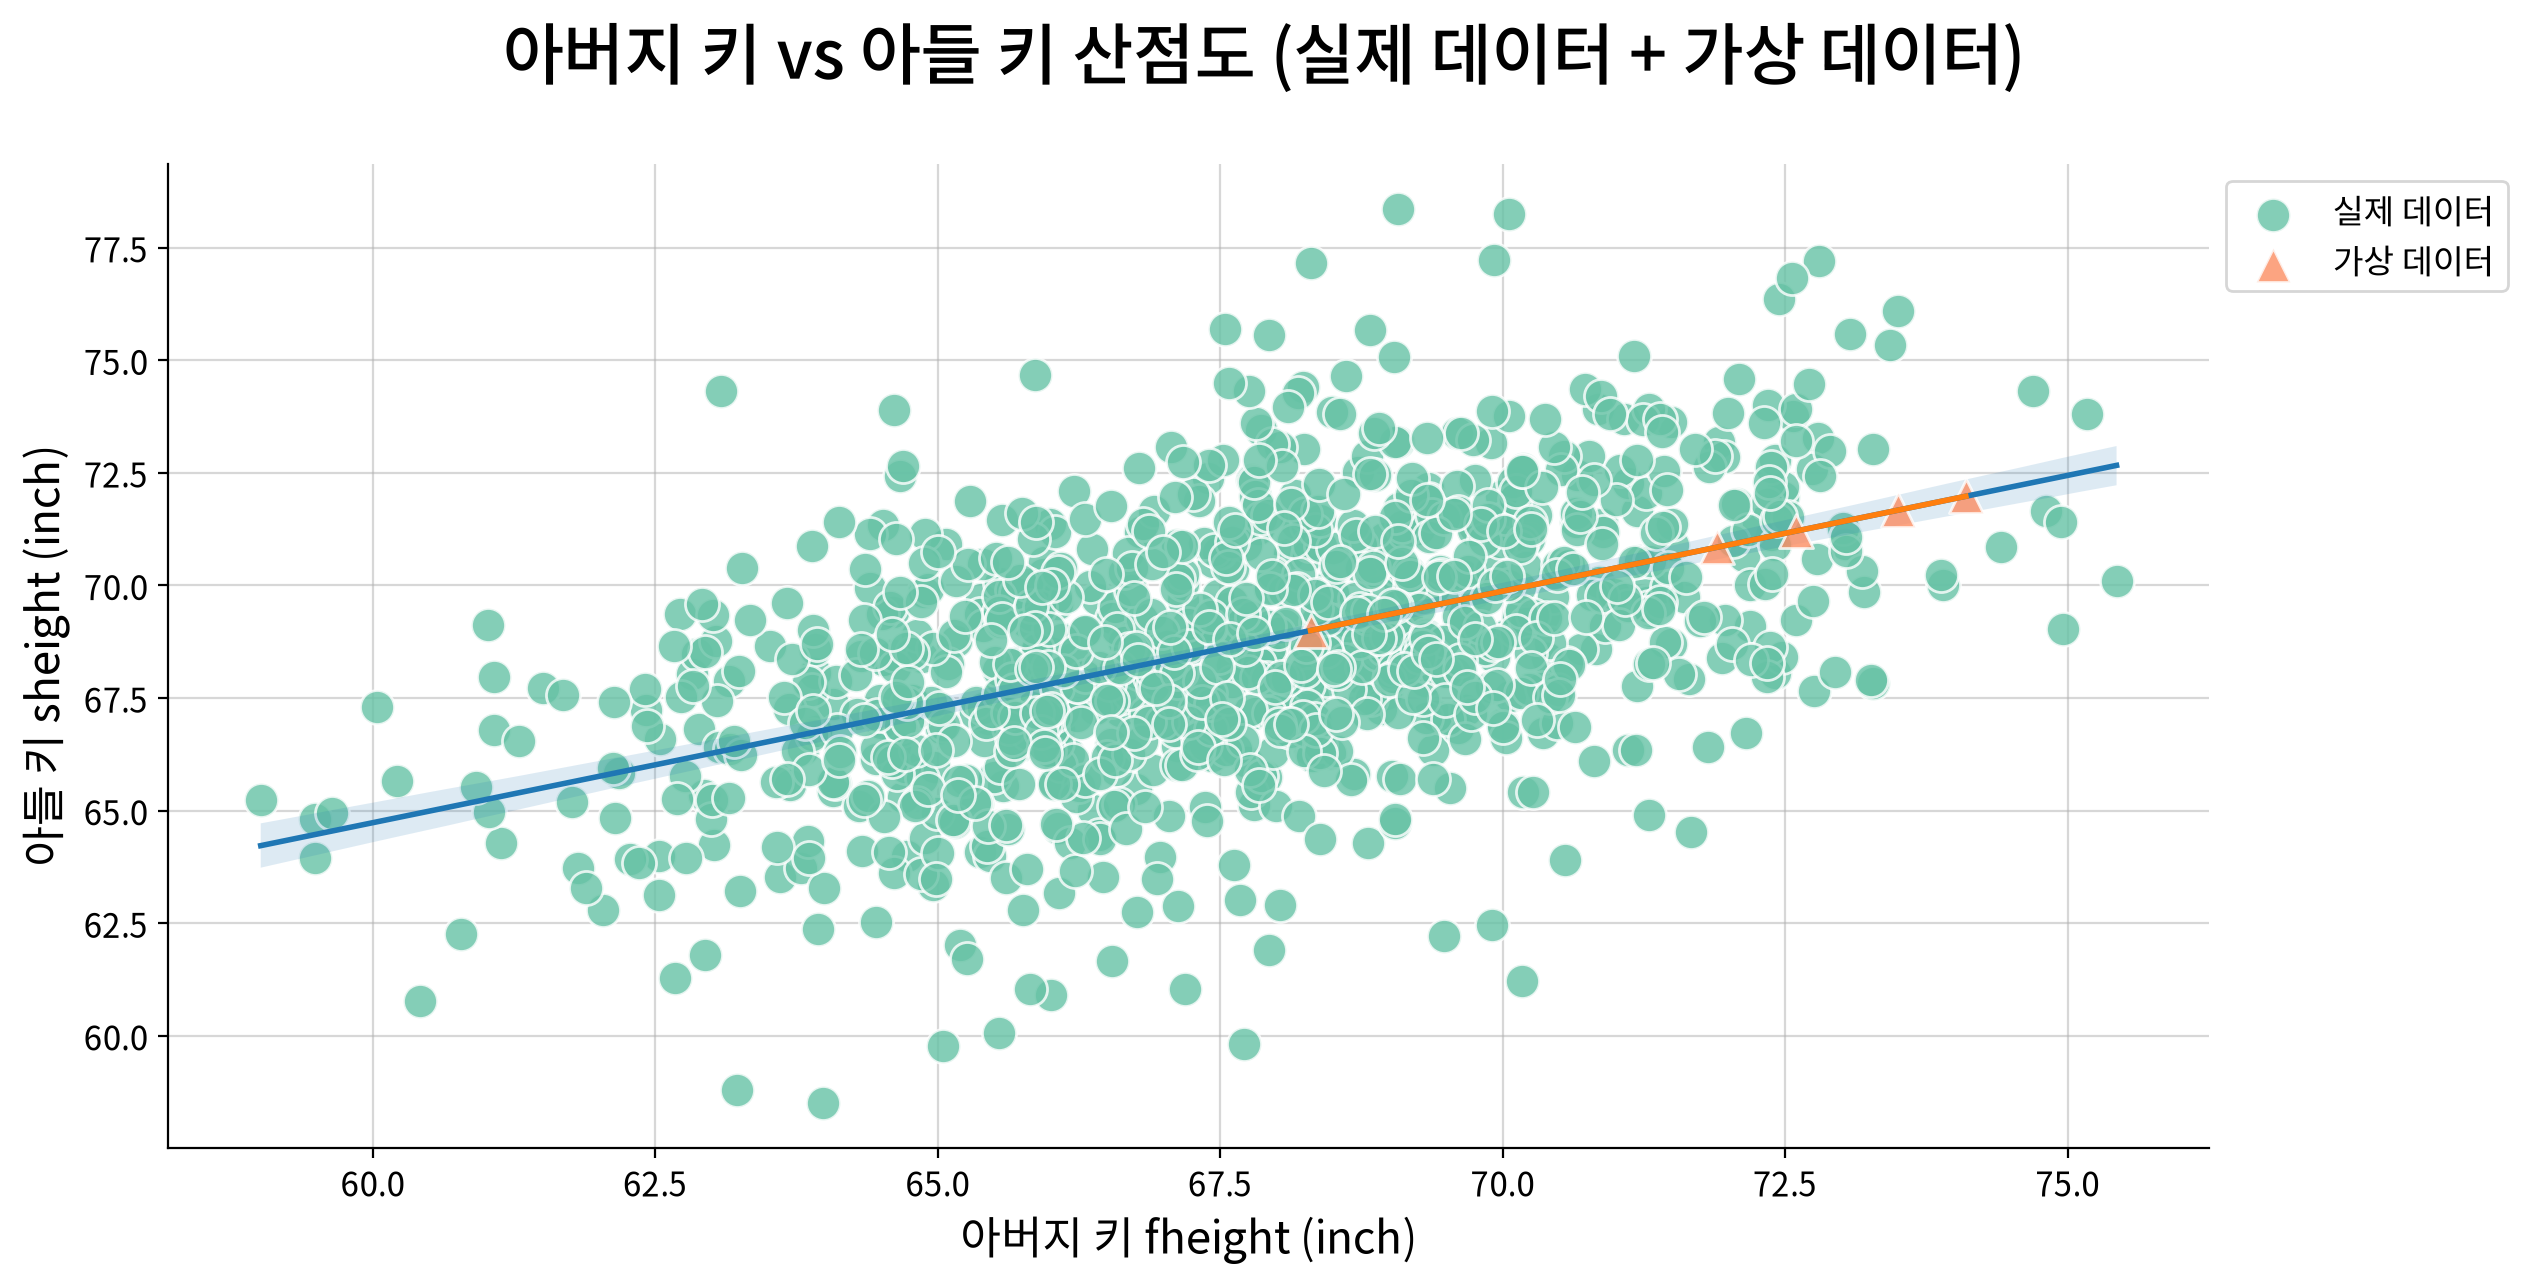

In [11]:
my_plot.lmplot(
    merged, x='fheight', y='sheight', hue='source',
    markers=['o', '^'], palette='Set2', scatter_size=150,
    title='아버지 키 vs 아들 키 산점도 (실제 데이터 + 가상 데이터)',
    xlabel='아버지 키 fheight (inch)', ylabel='아들 키 sheight (inch)')

### 📌 보고 요약

- 연두색 동그라미은 **실제 데이터 1,078명**, 주황색 삼각형은 **예측한 가상 5명**이다.
- 5개의 삼각형은 모두 **회귀 직선 위에 정확히** 놓여 있다 — 예측값이 회귀식 $\hat{sheight}=b_0+b_1\cdot fheight$ 를 그대로 따른다는 증거이다.
- 아버지 키가 큰 신청자일수록 예측된 아들 키도 커지며, 이는 Mission 1에서 확인한 양의 상관·선형 경향과 일치한다.